In [1]:
import numpy as np
import matplotlib.pyplot as plt

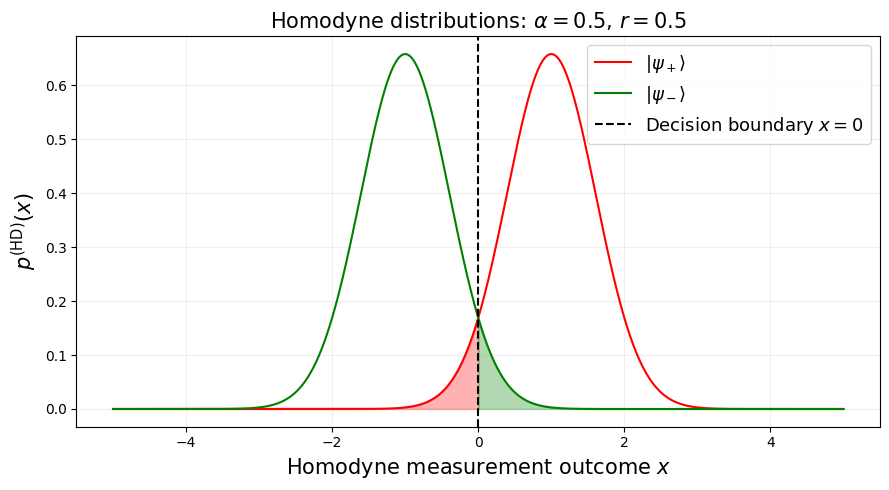

In [7]:
# Parameters
alpha = 0.5
r = 0.5

# x-axis
x = np.linspace(-5, 5, 2000)

# Variance and standard deviation
variance = np.exp(-2*r)
sigma = np.exp(-r)

# Homodyne probability distributions
p_plus = (1 / np.sqrt(2*np.pi*variance)) * np.exp(-(x - 2*alpha)**2 / (2*variance))

p_minus = (1 / np.sqrt(2*np.pi*variance)) * np.exp(-(x + 2*alpha)**2 / (2*variance))

# Create figure
plt.figure(figsize=(9, 5), dpi=100)

# Plot distributions
plt.plot(x, p_plus, label=r'$|\psi_+\rangle$', color='r')
plt.plot(x, p_minus, label=r'$|\psi_-\rangle$', color='g')

# Shade error regions
error_plus = x < 0
error_minus = x >= 0

plt.fill_between(x[error_plus], p_plus[error_plus], alpha=0.3, color='r')

plt.fill_between(x[error_minus], p_minus[error_minus], alpha=0.3,  color='g')

# Decision boundary
plt.axvline(0, color='k', linestyle='--', linewidth=1.5, label=r'Decision boundary $x=0$')

# Labels
plt.xlabel(r'Homodyne measurement outcome $x$', fontsize=15)
plt.ylabel(r'$p^{(\mathrm{HD})}(x)$', fontsize=15)

plt.title(rf'Homodyne distributions: ' rf'$\alpha={alpha}$, $r={r}$', fontsize=15)

plt.legend(fontsize=13)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('plots/homodyne_noise_free.pdf')
plt.show()

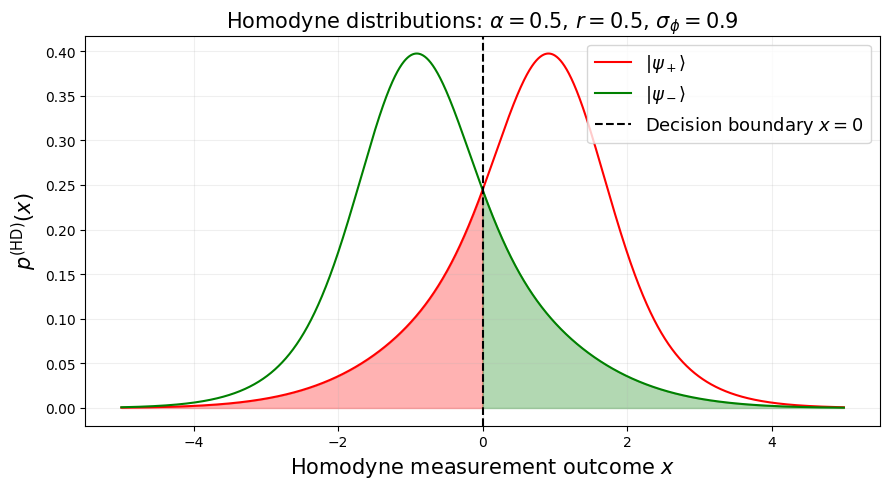

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# Parameters

alpha = 0.5
r = 0.5
sigma_phi = 0.5     # phase-noise standard deviation

# x-axis

x = np.linspace(-5, 5, 2000)

# Phase axis

phi = np.linspace(-5*sigma_phi, 5*sigma_phi, 2000)

# Gaussian phase-noise distribution P_sigma(phi)

P_sigma = (
    1 / np.sqrt(2*np.pi*sigma_phi**2)
    * np.exp(-phi**2 / (2*sigma_phi**2))
)

# Variance V(phi,r)

V = (
    np.exp(-2*r) * np.cos(phi)**2
    + np.exp(2*r) * np.sin(phi)**2
)

# Homodyne probability distributions

X, PHI = np.meshgrid(x, phi, indexing='ij')

V_2D = V[None, :]

P_plus_integrand = (
    P_sigma[None, :]
    / np.sqrt(2*np.pi*V_2D)
    * np.exp(
        -(X - 2*abs(alpha)*np.cos(PHI))**2
        / (2*V_2D)
    )
)

P_minus_integrand = (
    P_sigma[None, :]
    / np.sqrt(2*np.pi*V_2D)
    * np.exp(
        -(X + 2*abs(alpha)*np.cos(PHI))**2
        / (2*V_2D)
    )
)

# Integrate over phi

p_plus = simpson(P_plus_integrand, x=phi, axis=1)
p_minus = simpson(P_minus_integrand, x=phi, axis=1)


# Create figure

plt.figure(figsize=(9, 5), dpi=100)

# Plot distributions

plt.plot(
    x, p_plus,
    label=r'$|\psi_+\rangle$',
    color='r'
)

plt.plot(
    x, p_minus,
    label=r'$|\psi_-\rangle$',
    color='g'
)

# Shade error regions

error_plus = x < 0
error_minus = x >= 0

plt.fill_between(
    x[error_plus],
    p_plus[error_plus],
    alpha=0.3,
    color='r'
)

plt.fill_between(
    x[error_minus],
    p_minus[error_minus],
    alpha=0.3,
    color='g'
)

# Decision boundary

plt.axvline(
    0,
    color='k',
    linestyle='--',
    linewidth=1.5,
    label=r'Decision boundary $x=0$'
)

# Labels

plt.xlabel(
    r'Homodyne measurement outcome $x$',
    fontsize=15
)

plt.ylabel(
    r'$p^{(\mathrm{HD})}(x)$',
    fontsize=15
)

plt.title(
    rf'Homodyne distributions: '
    rf'$\alpha={alpha}$, $r={r}$, $\sigma_\phi={sigma_phi}$',
    fontsize=15
)

plt.legend(fontsize=13)

plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    'plots/homodyne_phase_noise.pdf'
)

plt.show()